Fragment Length and Normalizing Part

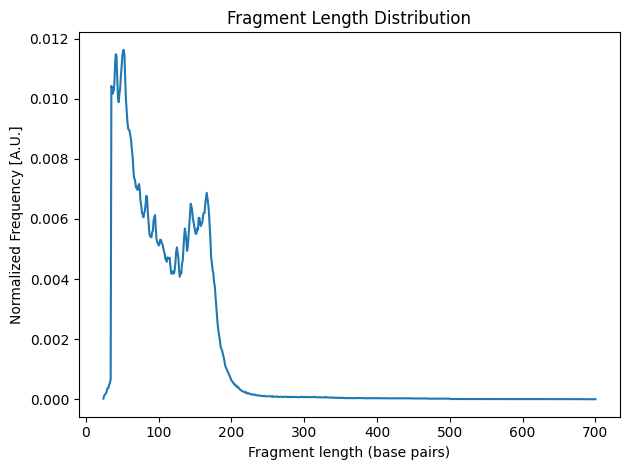

In [3]:

import gzip
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'query.bed.gz'
lengths = []

with gzip.open(file_path, 'rt') as f:
    try:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            cols = line.strip().split('\t')
            start, end = int(cols[1]), int(cols[2])
            lengths.append(end - start)
    except EOFError:
        # We reached at the end of the gzip stream; stop reading further.
        pass

# Create a DataFrame of fragment lengths
df = pd.DataFrame({'length': lengths})

# Count frequencies
freq = df['length'].value_counts().sort_index()
normalized_freq = freq / freq.sum()

# Plot
plt.figure()
plt.plot(normalized_freq.index, normalized_freq.values)
plt.xlabel('Fragment length (base pairs)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')
plt.tight_layout()
plt.show()

RESCALING

<ipython-input-5-9d64080f0aa3>:7: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  q_df = pd.read_csv(


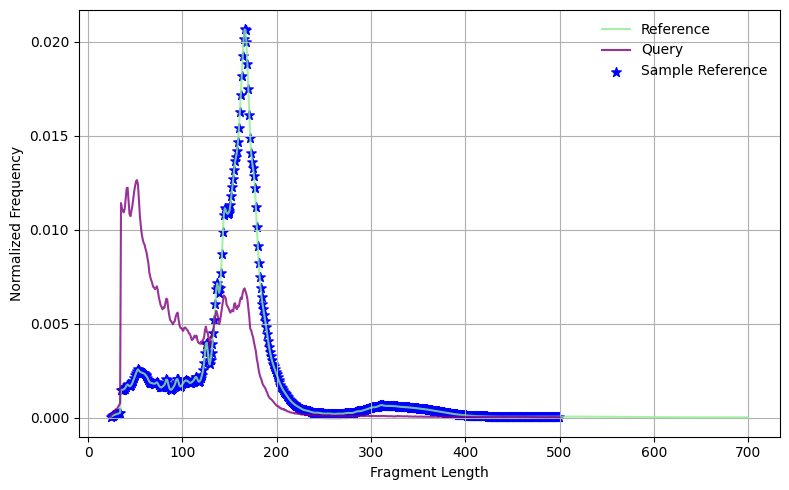

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

# LOADING THE  DATA
q_df = pd.read_csv(
    'query.bed.gz',
    sep='\t',
    header=None,
    compression='gzip'
)
# LOADING THE REFERENCE HISTOGRAM
ref_data = pd.read_csv(
    'reference.hist',
    header=None,
    sep='\t'
)

ref_data[0] = pd.to_numeric(ref_data[0], errors='coerce')

# Assigning the  column names to match BED fields
q_df.columns = ['Chrom', 'Start', 'End', 'Length', 'Dot', 'Strand']

q_df['Length'] = pd.to_numeric(q_df['Length'], errors='coerce')
q_df = q_df.dropna(subset=['Length'])


# DEFINING BINS
b_edges = list(range(0, 510, 10))
b_labels = [f"{i}-{i+10}" for i in range(0, 500, 10)]

q_df['Bin'] = pd.cut(
    q_df['Length'], bins=b_edges,
    labels=b_labels, right=False
)
ref_data['Bin'] = pd.cut(
    ref_data[0], bins=b_edges,
    labels=b_labels, right=False
)

# COUNTING THE  ENTRIES PER BIN
qbn     = q_df['Bin'].value_counts().sort_index()
rbn = ref_data['Bin'].value_counts().sort_index()

m_sampl_rows = []
for label in b_labels:
    cnt_q     = qbn.get(label, 0)
    cnt_r = rbn.get(label, 0)
    sam_size     = min(cnt_q, cnt_r)

    if sam_size > 0:
        reference_subset = ref_data[ref_data['Bin'] == label]
        s_s   = reference_subset.sample(
            n=sam_size, random_state=42
        )
        m_sampl_rows.append(s_s)

# Combining all sampled reference rows
if m_sampl_rows:
    sampled_reference_df = pd.concat(
        m_sampl_rows, ignore_index=True
    )
else:
    sampled_reference_df = pd.DataFrame(columns=ref_data.columns)

# Computing Query Distribution
le_cnt = q_df['Length'].value_counts().sort_index()
le_freq   = le_cnt / le_cnt.sum()
query_freq_df = pd.DataFrame({
    'Length':    le_freq.index,
    'Frequency': le_freq.values
})

# Plotting  Begins
plt.figure(figsize=(8, 5))

# Reference histogram as a light-green line
plt.plot(
    ref_data[0], ref_data[1],
    color='lightgreen',
    label='Reference',
    linewidth=1.5,
    alpha=0.8
)

# Query distribution as a purple line
plt.plot(
    query_freq_df['Length'], query_freq_df['Frequency'],
    color='purple',
    label='Query',
    linewidth=1.5,
    alpha=0.8
)

# Sampled-reference points as blue stars
plt.scatter(
    sampled_reference_df[0], sampled_reference_df[1],
    color='blue',
    marker='*',
    s=50,
    label='Sample Reference'
)

plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.legend(loc='upper right', frameon=False)
plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()
